### ScholarAgent: Agent Graph Test & Visualization
**Objective:**
1. Test the execution flow of our basic agent graph.
2. Visualize the architecture of our multi-agent system.

In [1]:
import os
import sys
from dotenv import load_dotenv

# Add project root to Python path

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Load environment variables.
load_dotenv(os.path.join(project_root,'.env'))


True

#### 1. Import and Visualize the Graph
First, we'll import our compiled `agent_graph` and use LangGraph's built-in methods to render it as an image. This confirms the structure is correct.

2025-08-31 00:53:28,635 - src.agent.tools - INFO - Initializing tools...
2025-08-31 00:53:28,636 - src.rag_pipeline.core - INFO - Creating the RAG chain for evaluation...
/workspaces/scholar-agent/src/rag_pipeline/core.py:40: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = SentenceTransformerEmbeddings(
/workspaces/scholar-agent/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/workspaces/scholar-agent/src/rag_pipeline/core.py:45: LangChainDeprecation

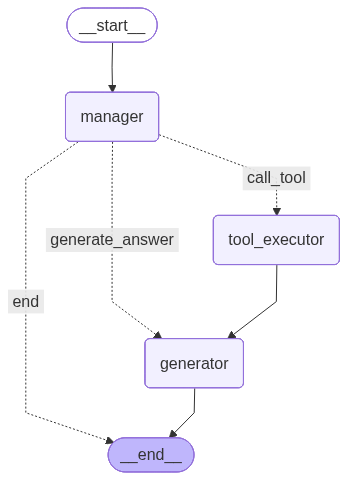

In [2]:
from src.agent.graph import agent_graph
from IPython.display import Image
try:
    png_data = agent_graph.get_graph().draw_mermaid_png()
    display(Image(png_data))
except Exception as e:
    print(f" Error generating the graph image.")
    print(f"Please ensure you have run: sudo apt-get update && sudo apt-get install -y graphviz libgraphviz-dev")

#### 2. Test the Execution Flow
Now, we'll invoke the graph with an initial message. We should see the print statements from each node execute in the correct order: Manager -> Searcher -> Writer.

In [3]:
from langchain_core.messages import HumanMessage
test_question = "What is the core problem with polysemantic neurons?"
initial_input = {"messages": [HumanMessage(content=test_question)]}
print("Invoking agent graph...")

final_state = agent_graph.invoke(initial_input)
print(f"Agent execution finished...")
print(f" Final state: ")
print(final_state)

2025-08-31 00:55:08,058 - src.agent.graph - INFO - Manager node executing.


Invoking agent graph...


2025-08-31 00:55:08,497 - src.agent.graph - INFO - Manager response: content='' additional_kwargs={'function_call': {'name': 'research_paper_search', 'arguments': '{"__arg1": "core problem with polysemantic neurons"}'}} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash', 'safety_ratings': []} id='run--9a235c42-99b1-44c6-9f30-6fa7cd447a2c-0' tool_calls=[{'name': 'research_paper_search', 'args': {'__arg1': 'core problem with polysemantic neurons'}, 'id': '1ae1511a-1df1-44f4-93c9-d2ccbf543b1a', 'type': 'tool_call'}] usage_metadata={'input_tokens': 89, 'output_tokens': 14, 'total_tokens': 103, 'input_token_details': {'cache_read': 0}}
2025-08-31 00:55:08,498 - src.agent.graph - INFO - Router checking the last message...
2025-08-31 00:55:08,499 - src.agent.graph - INFO - Decision: Call tools.
2025-08-31 00:55:08,501 - src.agent.graph - INFO - Tool node executing.
2025-08-31 00:55:08,501 - src.agent.graph

Agent execution finished...
 Final state: 
{'messages': [HumanMessage(content='What is the core problem with polysemantic neurons?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'function_call': {'name': 'research_paper_search', 'arguments': '{"__arg1": "core problem with polysemantic neurons"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-1.5-flash', 'safety_ratings': []}, id='run--9a235c42-99b1-44c6-9f30-6fa7cd447a2c-0', tool_calls=[{'name': 'research_paper_search', 'args': {'__arg1': 'core problem with polysemantic neurons'}, 'id': '1ae1511a-1df1-44f4-93c9-d2ccbf543b1a', 'type': 'tool_call'}], usage_metadata={'input_tokens': 89, 'output_tokens': 14, 'total_tokens': 103, 'input_token_details': {'cache_read': 0}}), ToolMessage(content="{'answer': 'Polysemantic neurons respond to multiple unrelated inputs, complicating function assignment.  This makes it diffic

In [4]:
import ast
tool_message = final_state["messages"][-1]
raw = tool_message.content
try:
    parsed = ast.literal_eval(raw)   # works if dict-like string
    answer = parsed.get("answer", raw)
except Exception:
    answer = raw   # fallback to plain text

print(answer)


Polysemantic neurons respond to multiple unrelated inputs, making function assignment difficult.  It is challenging to determine the precise proportion of activations attributed to each feature and their impact on the output because each neuron is activated by multiple features, creating a one-to-many mapping.  Interpreting their behavior based on individual activations alone is also difficult.
